In [2]:
# ==============================
# 1️⃣ Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ==============================
# 2️⃣ Load Dataset
# ==============================

# Change file name if needed
data = pd.read_e("Renewable_Energy_Data.xlsx")

print("Dataset Preview:")
print(data.head())

# ==============================
# 3️⃣ Data Preprocessing
# ==============================

# Convert Date column to datetime
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)

# Extract useful time features
data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month

# Drop Date column (optional)
data = data.drop("Date", axis=1)

# Define features (X) and target (y)
X = data.drop("Daily_PowerOutput_kW", axis=1)
y = data["Daily_PowerOutput_kW"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 4️⃣ Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==============================
# 5️⃣ Model Training
# ==============================

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==============================
# 6️⃣ Prediction
# ==============================

y_pred = model.predict(X_test)

# ==============================
# 7️⃣ Model Evaluation
# ==============================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==============================
# 8️⃣ Visualization
# ==============================

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Solar Power Output")
plt.show()

# ==============================
# 9️⃣ Feature Importance
# ==============================

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

Dataset Preview:
        Date  Hour  Temperature_C  Humidity_%  WindSpeed_mps  CloudCover_%  \
0 2024-01-01     6             18          72            2.5            40   
1 2024-01-01     7             20          70            3.1            35   
2 2024-01-01     8             23          65            3.8            20   
3 2024-01-01     9             26          60            4.2            15   
4 2024-01-01    10             29          55            4.5            10   

   SolarIrradiance_Wm2  Pressure_hPa  Rainfall_mm  PowerOutput_kW  
0                  120          1012            0              15  
1                  250          1011            0              45  
2                  480          1010            0             120  
3                  650          1009            0             210  
4                  820          1008            0             320  


KeyError: "['Daily_PowerOutput_kW'] not found in axis"

In [5]:
# Load Excel file
data = pd.read_excel("Renewable_Energy_Data.xlsx")

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

print("Column Names:")
print(data.columns)

# Convert Date column
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True, errors='coerce')

# Extract time features
data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month

# Drop Date column
data = data.drop("Date", axis=1)

# 👇 IMPORTANT: Use the correct target column name
target_column = "DailyPowerOutputW"   # Change if needed

X = data.drop(columns=[target_column])
y = data[target_column]


Column Names:
Index(['Date', 'Hour', 'Temperature_C', 'Humidity_%', 'WindSpeed_mps',
       'CloudCover_%', 'SolarIrradiance_Wm2', 'Pressure_hPa', 'Rainfall_mm',
       'PowerOutput_kW'],
      dtype='object')


KeyError: "['DailyPowerOutputW'] not found in axis"

Dataset Preview:
        Date  Hour  Temperature_C  Humidity_%  WindSpeed_mps  CloudCover_%  \
0 2024-01-01     6             18          72            2.5            40   
1 2024-01-01     7             20          70            3.1            35   
2 2024-01-01     8             23          65            3.8            20   
3 2024-01-01     9             26          60            4.2            15   
4 2024-01-01    10             29          55            4.5            10   

   SolarIrradiance_Wm2  Pressure_hPa  Rainfall_mm  PowerOutput_kW  
0                  120          1012            0              15  
1                  250          1011            0              45  
2                  480          1010            0             120  
3                  650          1009            0             210  
4                  820          1008            0             320  

Column Names:
Index(['Date', 'Hour', 'Temperature_C', 'Humidity_%', 'WindSpeed_mps',
       'CloudCover_%

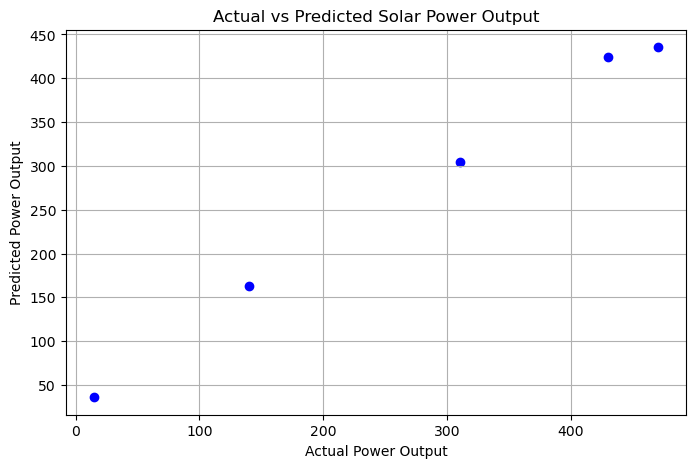

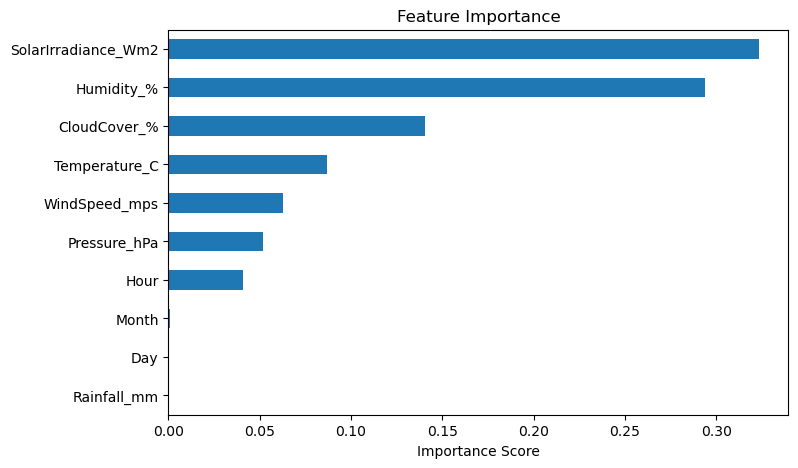

In [6]:
# ==============================
# 1️⃣ Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ==============================
# 2️⃣ Load Dataset
# ==============================

# ⚠️ Correct function for Excel is read_excel, not read_e
data = pd.read_excel("Renewable_Energy_Data.xlsx")

# Remove extra spaces in column names (common issue with Excel)
data.columns = data.columns.str.strip()

print("Dataset Preview:")
print(data.head())

print("\nColumn Names:")
print(data.columns)

# ==============================
# 3️⃣ Data Preprocessing
# ==============================

# Convert Date column to datetime
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True, errors='coerce')

# Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

# Extract useful time features
data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month

# Drop Date column
data = data.drop("Date", axis=1)

# ==============================
# 4️⃣ Define Features and Target
# ==============================

# ⚠️ Make sure your target column exists; adjust the name if necessary
target_column = "PowerOutput_kW"  # Replace with your column name if different
if target_column not in data.columns:
    print(f"⚠️ Target column '{target_column}' not found! Check your Excel file columns.")
else:
    X = data.drop(columns=[target_column])
    y = data[target_column]

    # Feature Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ==============================
    # 5️⃣ Train-Test Split
    # ==============================

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ==============================
    # 6️⃣ Model Training
    # ==============================

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # ==============================
    # 7️⃣ Prediction
    # ==============================

    y_pred = model.predict(X_test)

    # ==============================
    # 8️⃣ Model Evaluation
    # ==============================

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nModel Performance:")
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2 Score:", round(r2, 3))

    # ==============================
    # 9️⃣ Visualization
    # ==============================

    plt.figure(figsize=(8,5))
    plt.scatter(y_test, y_pred, color='blue')
    plt.xlabel("Actual Power Output")
    plt.ylabel("Predicted Power Output")
    plt.title("Actual vs Predicted Solar Power Output")
    plt.grid(True)
    plt.show()

    # ==============================
    # 🔟 Feature Importance
    # ==============================

    feature_importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    )

    plt.figure(figsize=(8,5))
    feature_importance.sort_values().plot(kind='barh')
    plt.title("Feature Importance")
    plt.xlabel("Importance Score")
    plt.show()
